## Tensorflow and Keras

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential

## Neuron without activation - Regression/Linear Model

### Dataset

In [9]:
X_train = np.array([
    [1.0],
    [2.0]
])
Y_train = np.array([
    [300.0],
    [500.0]
])

print(f"Shape of X: {X_train.shape} \nShape of Y: {Y_train.shape}")

Shape of X: (2, 1) 
Shape of Y: (2, 1)


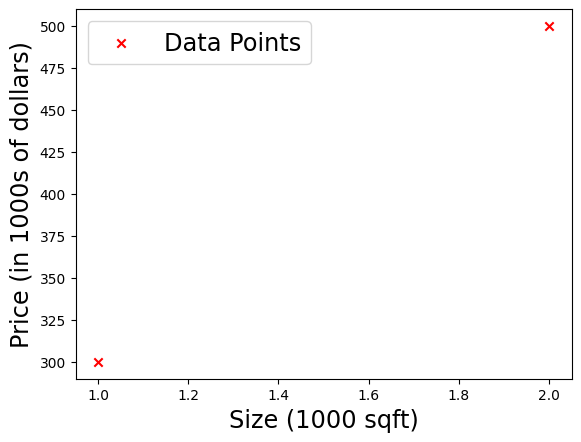

In [10]:
fig, ax = plt.subplots(1,1)
ax.scatter(X_train, Y_train, marker='x', c='r', label='Data Points')
ax.legend( fontsize='xx-large')
ax.set_ylabel('Price (in 1000s of dollars)', fontsize='xx-large')
ax.set_xlabel('Size (1000 sqft)', fontsize='xx-large')
plt.show()

### Regression/Linear Model

In [28]:
linear_layer = tf.keras.layers.Dense(units=1, activation='linear')

Let's examine the weights

In [29]:
linear_layer.get_weights()

[]

There are no weights as the weights are not yet instantiated. Let's try the model on one example in `X_train`. This will trigger the instantiation of the weights. Note, the input to the layer must be 2-D, so we'll reshape it.

In [32]:
a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)

tf.Tensor([[1.3481427]], shape=(1, 1), dtype=float32)


The result is a tensor (another name for an array) with a shape of (1,1) or one entry.   
Now let's look at the weights and bias. These weights are randomly initialized to small numbers and the bias defaults to being initialized to zero.

In [33]:
w, b = linear_layer.get_weights()
print(f"w= {w}, b= {b}")

w= [[1.3481427]], b= [0.]


The weights are initialized to random values so let's set them to some known values.

In [35]:
set_w = np.array([[200]])
set_b = np.array([100])

linear_layer.set_weights([set_w,set_b])

w, b = linear_layer.get_weights()
print(f"w= {w}, b= {b}")

w= [[200.]], b= [100.]


Let's do a manual comparison

In [37]:
a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)

a1_manual = np.dot(set_w, X_train[0].reshape(1,1)) + set_b
print(a1_manual)

tf.Tensor([[300.]], shape=(1, 1), dtype=float32)
[[300.]]


Make some predictions

In [38]:
y_pred = linear_layer(X_train)
print(y_pred)

tf.Tensor(
[[300.]
 [500.]], shape=(2, 1), dtype=float32)


### Neuron with Sigmoid Activation

#### Dataset

In [44]:
X_train = np.array([0,1,2,3,4,5], dtype=np.float32).reshape(-1,1)
Y_train = np.array([0,0,0,1,1,1], dtype=np.float32).reshape(-1,1)

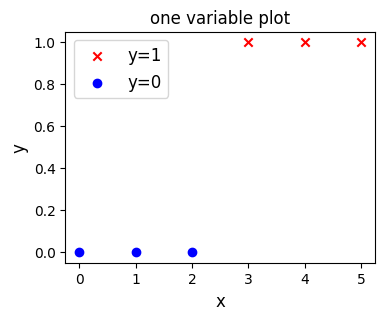

In [46]:
pos = Y_train == 1
neg = Y_train == 0

fig, ax = plt.subplots(1,1,figsize=(4,3))
ax.scatter(X_train[pos], Y_train[pos], marker='x', c='r', label='y=1')
ax.scatter(X_train[neg], Y_train[neg], marker='o', c='b', label='y=0')

ax.set_ylabel('y', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.set_title('one variable plot')
ax.legend(fontsize=12)
plt.show()

### Logistic Neuron
We can implement a 'logistic neuron' by adding a sigmoid activation. The function of the neuron is then described by (2) above.   
This section will create a Tensorflow Model that contains our logistic layer to demonstrate an alternate method of creating models. Tensorflow is most often used to create multi-layer models. The [Sequential](https://keras.io/guides/sequential_model/) model is a convenient means of constructing these models.

In [49]:
model = Sequential(
    [
        tf.keras.layers.Dense(units=1, input_dim=1, activation='sigmoid', name='L1')
    ]
)

`model.summary()` shows the layers and number of parameters in the model. There is only one layer in this model and that layer has only one unit. The unit has two parameters, $w$ and $b$.

In [50]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
logistic_layer = model.get_layer('L1')
print(logistic_layer)

w, b = logistic_layer.get_weights()
print(f"w= {w}, b= {b}")
print(f"w_shape= {w.shape}, b_shape= {b.shape}")

<Dense name=L1, built=True>
w= [[-0.93824714]], b= [0.]
w_shape= (1, 1), b_shape= (1,)


Let's make a prediction

In [56]:
a1 = model.predict(X_train[0].reshape(-1,1))
print(a1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[0.5]]
